In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

In [3]:
data = pd.read_csv("nifty50_historical_data.csv")

In [4]:
data.head()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
0,1999-01-01 00:00:00+05:30,AXISBANK.NS,Axis Bank Ltd.,Financials,2.198795,2.212041,2.139190,2.165681,337500,0.0,...,4257978515456,16.260086,13.534726,NaN,2.055485,0.07,84.28,0.313,1378.70,978.05
1,1999-01-01 00:00:00+05:30,BPCL.NS,Bharat Petroleum Corporation Ltd.,Energy,3.059547,3.083643,3.035450,3.073874,324744,0.0,...,1581385383936,6.329224,7.975497,NaN,1.658039,4.80,57.59,0.981,388.15,234.01
2,1999-01-01 00:00:00+05:30,BRITANNIA.NS,Britannia Industries Ltd.,FMCG,40.944134,40.974527,40.775792,40.845936,42000,0.0,...,1411608608768,60.977005,48.923096,NaN,37.810410,1.28,96.11,0.572,6336.00,4506.00
3,1999-01-01 00:00:00+05:30,CIPLA.NS,Cipla Ltd.,Pharma,19.149712,19.580167,19.006226,19.426748,108750,0.0,...,1069501579264,23.529411,23.371544,NaN,3.248832,0.98,56.27,0.042,1673.00,1281.70
4,1999-01-01 00:00:00+05:30,DRREDDY.NS,Dr. Reddy's Laboratories Ltd.,Pharma,21.000834,21.293348,21.000834,21.185806,2324000,0.0,...,1014151315456,17.929054,22.147236,NaN,2.723533,0.66,67.94,0.315,1379.70,1020.00


In [5]:
data.tail()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
287305,2026-01-30 00:00:00+05:30,TCS.NS,Tata Consultancy Services Ltd.,IT,3141.000000,3141.0,3092.000000,3123.899902,3022068,0.0,...,11302543032320,23.696426,20.320614,NaN,9.957383,2.02,131.83,0.302,4150.0,2866.60
287306,2026-01-30 00:00:00+05:30,TECHM.NS,Tech Mahindra Ltd.,IT,1757.099976,1760.0,1731.000000,1743.099976,1672787,0.0,...,1543527858176,33.443977,22.998941,NaN,5.615983,2.58,52.12,0.208,1776.6,1209.40
287307,2026-01-30 00:00:00+05:30,TITAN.NS,Titan Company Ltd.,Consumer Durables,3945.000000,3995.0,3909.800049,3977.399902,1427639,0.0,...,3528133705728,85.461970,59.151726,NaN,27.548708,0.28,46.54,0.118,4312.1,2925.00
287308,2026-01-30 00:00:00+05:30,ULTRACEMCO.NS,UltraTech Cement Ltd.,Cement,12649.000000,12725.0,12536.000000,12694.000000,296848,0.0,...,3733783838720,48.691982,32.835144,NaN,5.183575,0.61,260.70,0.346,13097.0,10047.85
287309,2026-01-30 00:00:00+05:30,WIPRO.NS,Wipro Ltd.,IT,238.000000,238.0,235.300003,236.899994,11362317,0.0,...,2481693917184,18.756927,17.592703,NaN,2.767135,7.18,12.63,0.555,323.6,228.00


In [6]:
data.shape

(287310, 25)

In [7]:
data.columns

Index(['Date', 'Ticker', 'Company_Name', 'Sector', 'Open', 'High', 'Low',
       'Close', 'Volume', 'Dividend', 'Stock_Split', 'Daily_Return',
       'Volatility_20D', 'MA_50', 'MA_200', 'Market_Cap', 'PE_Ratio',
       'Forward_PE', 'PEG_Ratio', 'Price_to_Book', 'Dividend_Yield', 'EPS',
       'Beta', '52Week_High', '52Week_Low'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287310 entries, 0 to 287309
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            287310 non-null  object 
 1   Ticker          287310 non-null  object 
 2   Company_Name    287310 non-null  object 
 3   Sector          287310 non-null  object 
 4   Open            287310 non-null  float64
 5   High            287310 non-null  float64
 6   Low             287310 non-null  float64
 7   Close           287310 non-null  float64
 8   Volume          287310 non-null  int64  
 9   Dividend        287310 non-null  float64
 10  Stock_Split     98 non-null      float64
 11  Daily_Return    287261 non-null  float64
 12  Volatility_20D  286330 non-null  float64
 13  MA_50           284909 non-null  float64
 14  MA_200          277559 non-null  float64
 15  Market_Cap      287310 non-null  int64  
 16  PE_Ratio        281453 non-null  float64
 17  Forward_PE

In [9]:
data.describe()

,Open,High,Low,Close,Volume,Dividend,Stock_Split,Daily_Return,Volatility_20D,MA_50,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
count,287310.000000,287310.000000,287310.000000,287310.000000,2.873100e+05,287310.000000,98.000000,287261.000000,286330.000000,284909.000000,...,2.873100e+05,281453.000000,287310.000000,0.0,287310.000000,281453.000000,287310.000000,283551.000000,287310.000000,287310.000000
mean,940.283620,951.740569,927.950491,939.614136,8.064757e+06,0.042278,3.265412,0.001943,0.024809,933.356778,...,4.181424e+12,34.312064,27.133530,NaN,7.286666,1.638649,89.762003,0.318788,3642.977069,2583.723222
std,2457.975005,2486.870766,2426.231206,2455.886319,1.860599e+07,1.338670,2.670567,0.216306,0.215389,2439.073050,...,3.819222e+12,20.188516,14.965564,NaN,9.884414,1.782466,103.628972,0.229752,5440.636350,4079.800545
min,-0.012947,-0.012995,-0.012433,-0.012851,0.000000e+00,0.000000,0.043750,-5.676113,0.000000,-0.007684,...,6.981300e+11,6.329224,7.200945,NaN,0.919242,0.050000,-26.230000,-0.109000,202.990000,125.300000
25%,70.237098,71.436894,68.887683,70.109819,6.296895e+05,0.000000,2.000000,-0.009882,0.013340,70.993137,...,1.771073e+12,19.800245,17.381470,NaN,2.531458,0.500000,30.480000,0.175000,1082.500000,680.000000
50%,236.307412,239.866478,232.499912,236.094742,2.404242e+06,0.000000,2.000000,0.000000,0.017510,236.410760,...,2.966612e+12,30.211220,22.947546,NaN,4.601731,0.980000,60.600000,0.259000,1752.500000,1281.700000
75%,816.242023,826.525145,805.341565,815.629150,8.013830e+06,0.000000,4.750000,0.011101,0.023770,811.248610,...,4.587704e+12,44.247370,32.835144,NaN,7.842478,2.020000,93.640000,0.417000,4150.000000,2866.600000
max,32398.188356,32398.188356,31575.519038,32253.597656,8.552157e+08,210.000000,10.000000,108.493070,24.272505,30651.896523,...,1.888321e+13,85.461970,68.110050,NaN,57.940514,7.180000,477.630000,0.981000,32490.000000,25360.000000


In [10]:
data.isnull()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287305,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
287306,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
287307,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
287308,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [11]:
data.isnull().sum()

Date                   0
Ticker                 0
Company_Name           0
Sector                 0
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
Dividend               0
Stock_Split       287212
Daily_Return          49
Volatility_20D       980
MA_50               2401
MA_200              9751
Market_Cap             0
PE_Ratio            5857
Forward_PE             0
PEG_Ratio         287310
Price_to_Book          0
Dividend_Yield      5857
EPS                    0
Beta                3759
52Week_High            0
52Week_Low             0
dtype: int64

In [12]:
data.duplicated().sum()

0

In [13]:
# Data Cleaning

In [14]:
data['Date'] = pd.to_datetime(data['Date'])

In [15]:
data['Date'].dtype

datetime64[ns, pytz.FixedOffset(330)]

In [16]:
data['Year'] = data['Date'].dt.year

In [17]:
data[['Date', 'Year']].head()

,Date,Year
0,1999-01-01 00:00:00+05:30,1999
1,1999-01-01 00:00:00+05:30,1999
2,1999-01-01 00:00:00+05:30,1999
3,1999-01-01 00:00:00+05:30,1999
4,1999-01-01 00:00:00+05:30,1999


In [18]:
data.duplicated().sum()

0

In [19]:
data.isnull().sum()

Date                   0
Ticker                 0
Company_Name           0
Sector                 0
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
Dividend               0
Stock_Split       287212
Daily_Return          49
Volatility_20D       980
MA_50               2401
MA_200              9751
Market_Cap             0
PE_Ratio            5857
Forward_PE             0
PEG_Ratio         287310
Price_to_Book          0
Dividend_Yield      5857
EPS                    0
Beta                3759
52Week_High            0
52Week_Low             0
Year                   0
dtype: int64

In [20]:
data[['Dividend', 'Dividend_Yield', 'EPS', 'Close', 'Market_Cap']].describe()

,Dividend,Dividend_Yield,EPS,Close,Market_Cap
count,287310.000000,281453.000000,287310.000000,287310.000000,2.873100e+05
mean,0.042278,1.638649,89.762003,939.614136,4.181424e+12
std,1.338670,1.782466,103.628972,2455.886319,3.819222e+12
min,0.000000,0.050000,-26.230000,-0.012851,6.981300e+11
25%,0.000000,0.500000,30.480000,70.109819,1.771073e+12
50%,0.000000,0.980000,60.600000,236.094742,2.966612e+12
75%,0.000000,2.020000,93.640000,815.629150,4.587704e+12
max,210.000000,7.180000,477.630000,32253.597656,1.888321e+13


In [21]:
data['Company_Name'].nunique()

49

In [22]:
data['Company_Name'].unique()

array(['Axis Bank Ltd.', 'Bharat Petroleum Corporation Ltd.',
       'Britannia Industries Ltd.', 'Cipla Ltd.',
       "Dr. Reddy's Laboratories Ltd.", 'Eicher Motors Ltd.',
       'HDFC Bank Ltd.', 'Hindalco Industries Ltd.',
       'Hindustan Unilever Ltd.', 'Infosys Ltd.', 'ITC Ltd.',
       'Mahindra & Mahindra Ltd.', 'Oil & Natural Gas Corporation Ltd.',
       'Reliance Industries Ltd.', 'State Bank of India',
       'Sun Pharmaceutical Industries Ltd.',
       'Tata Consumer Products Ltd.', 'Tata Steel Ltd.',
       'Titan Company Ltd.', 'Wipro Ltd.', 'Kotak Mahindra Bank Ltd.',
       'Shree Cement Ltd.', 'Adani Enterprises Ltd.',
       'Apollo Hospitals Enterprise Ltd.', 'Asian Paints Ltd.',
       'Bajaj Auto Ltd.', 'Bajaj Finance Ltd.', 'Bharti Airtel Ltd.',
       'Grasim Industries Ltd.', 'Hero MotoCorp Ltd.', 'ICICI Bank Ltd.',
       'IndusInd Bank Ltd.', 'Larsen & Toubro Ltd.', 'Bajaj Finserv Ltd.',
       'HCL Technologies Ltd.', 'Nestle India Ltd.',
       'Tata Cons

In [23]:
data['Sector'].nunique()

13

In [24]:
data['Sector'].value_counts()

Financials           53903
FMCG                 32903
IT                   32345
Automobile           30842
Pharma               25983
Metals               22935
Energy               20301
Cement               17798
Infrastructure       16199
Consumer Durables    12626
Power                 9763
Healthcare            5856
Telecom               5856
Name: Sector, dtype: int64

In [25]:
df = data.copy()
df

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low,Year
0,1999-01-01 00:00:00+05:30,AXISBANK.NS,Axis Bank Ltd.,Financials,2.198795,2.212041,2.139190,2.165681,337500,0.0,...,16.260086,13.534726,NaN,2.055485,0.07,84.28,0.313,1378.70,978.05,1999
1,1999-01-01 00:00:00+05:30,BPCL.NS,Bharat Petroleum Corporation Ltd.,Energy,3.059547,3.083643,3.035450,3.073874,324744,0.0,...,6.329224,7.975497,NaN,1.658039,4.80,57.59,0.981,388.15,234.01,1999
2,1999-01-01 00:00:00+05:30,BRITANNIA.NS,Britannia Industries Ltd.,FMCG,40.944134,40.974527,40.775792,40.845936,42000,0.0,...,60.977005,48.923096,NaN,37.810410,1.28,96.11,0.572,6336.00,4506.00,1999
3,1999-01-01 00:00:00+05:30,CIPLA.NS,Cipla Ltd.,Pharma,19.149712,19.580167,19.006226,19.426748,108750,0.0,...,23.529411,23.371544,NaN,3.248832,0.98,56.27,0.042,1673.00,1281.70,1999
4,1999-01-01 00:00:00+05:30,DRREDDY.NS,Dr. Reddy's Laboratories Ltd.,Pharma,21.000834,21.293348,21.000834,21.185806,2324000,0.0,...,17.929054,22.147236,NaN,2.723533,0.66,67.94,0.315,1379.70,1020.00,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287305,2026-01-30 00:00:00+05:30,TCS.NS,Tata Consultancy Services Ltd.,IT,3141.000000,3141.000000,3092.000000,3123.899902,3022068,0.0,...,23.696426,20.320614,NaN,9.957383,2.02,131.83,0.302,4150.00,2866.60,2026
287306,2026-01-30 00:00:00+05:30,TECHM.NS,Tech Mahindra Ltd.,IT,1757.099976,1760.000000,1731.000000,1743.099976,1672787,0.0,...,33.443977,22.998941,NaN,5.615983,2.58,52.12,0.208,1776.60,1209.40,2026
287307,2026-01-30 00:00:00+05:30,TITAN.NS,Titan Company Ltd.,Consumer Durables,3945.000000,3995.000000,3909.800049,3977.399902,1427639,0.0,...,85.461970,59.151726,NaN,27.548708,0.28,46.54,0.118,4312.10,2925.00,2026
287308,2026-01-30 00:00:00+05:30,ULTRACEMCO.NS,UltraTech Cement Ltd.,Cement,12649.000000,12725.000000,12536.000000,12694.000000,296848,0.0,...,48.691982,32.835144,NaN,5.183575,0.61,260.70,0.346,13097.00,10047.85,2026


In [26]:
df[['Date', 'Year', 'Ticker', 'Company_Name', 'Sector',
    'Close', 'Dividend', 'Dividend_Yield', 'EPS']].head(10)

,Date,Year,Ticker,Company_Name,Sector,Close,Dividend,Dividend_Yield,EPS
0,1999-01-01 00:00:00+05:30,1999,AXISBANK.NS,Axis Bank Ltd.,Financials,2.165681,0.0,0.07,84.28
1,1999-01-01 00:00:00+05:30,1999,BPCL.NS,Bharat Petroleum Corporation Ltd.,Energy,3.073874,0.0,4.80,57.59
2,1999-01-01 00:00:00+05:30,1999,BRITANNIA.NS,Britannia Industries Ltd.,FMCG,40.845936,0.0,1.28,96.11
3,1999-01-01 00:00:00+05:30,1999,CIPLA.NS,Cipla Ltd.,Pharma,19.426748,0.0,0.98,56.27
4,1999-01-01 00:00:00+05:30,1999,DRREDDY.NS,Dr. Reddy's Laboratories Ltd.,Pharma,21.185806,0.0,0.66,67.94
5,1999-01-01 00:00:00+05:30,1999,EICHERMOT.NS,Eicher Motors Ltd.,Automobile,0.712911,0.0,0.99,185.59
6,1999-01-01 00:00:00+05:30,1999,HDFCBANK.NS,HDFC Bank Ltd.,Financials,2.191772,0.0,1.18,44.79
7,1999-01-01 00:00:00+05:30,1999,HINDALCO.NS,Hindalco Industries Ltd.,Metals,33.410904,0.0,0.52,79.90
8,1999-01-01 00:00:00+05:30,1999,HINDUNILVR.NS,Hindustan Unilever Ltd.,FMCG,90.686913,0.0,1.81,46.27
9,1999-01-01 00:00:00+05:30,1999,INFY.NS,Infosys Ltd.,IT,7.067403,0.0,2.74,70.89


In [27]:
df.isnull().sum()

Date                   0
Ticker                 0
Company_Name           0
Sector                 0
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
Dividend               0
Stock_Split       287212
Daily_Return          49
Volatility_20D       980
MA_50               2401
MA_200              9751
Market_Cap             0
PE_Ratio            5857
Forward_PE             0
PEG_Ratio         287310
Price_to_Book          0
Dividend_Yield      5857
EPS                    0
Beta                3759
52Week_High            0
52Week_Low             0
Year                   0
dtype: int64

In [28]:
(df.isnull().sum() / len(df) * 100).round(2)

Date                0.00
Ticker              0.00
Company_Name        0.00
Sector              0.00
Open                0.00
High                0.00
Low                 0.00
Close               0.00
Volume              0.00
Dividend            0.00
Stock_Split        99.97
Daily_Return        0.02
Volatility_20D      0.34
MA_50               0.84
MA_200              3.39
Market_Cap          0.00
PE_Ratio            2.04
Forward_PE          0.00
PEG_Ratio         100.00
Price_to_Book       0.00
Dividend_Yield      2.04
EPS                 0.00
Beta                1.31
52Week_High         0.00
52Week_Low          0.00
Year                0.00
dtype: float64

In [29]:
df[['Dividend', 'Dividend_Yield', 'EPS', 'Close', 'Market_Cap']].describe()

,Dividend,Dividend_Yield,EPS,Close,Market_Cap
count,287310.000000,281453.000000,287310.000000,287310.000000,2.873100e+05
mean,0.042278,1.638649,89.762003,939.614136,4.181424e+12
std,1.338670,1.782466,103.628972,2455.886319,3.819222e+12
min,0.000000,0.050000,-26.230000,-0.012851,6.981300e+11
25%,0.000000,0.500000,30.480000,70.109819,1.771073e+12
50%,0.000000,0.980000,60.600000,236.094742,2.966612e+12
75%,0.000000,2.020000,93.640000,815.629150,4.587704e+12
max,210.000000,7.180000,477.630000,32253.597656,1.888321e+13


In [30]:
# Clean the dataset

In [31]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage',
    ascending=False
)

,Missing_Count,Missing_Percentage
PEG_Ratio,287310,100.00
Stock_Split,287212,99.97
MA_200,9751,3.39
PE_Ratio,5857,2.04
Dividend_Yield,5857,2.04
Beta,3759,1.31
MA_50,2401,0.84
Volatility_20D,980,0.34
Daily_Return,49,0.02


In [32]:
df = df.drop(columns=['PEG_Ratio', 'Stock_Split'])

In [33]:
df.shape

(287310, 24)

In [34]:
df['Dividend'].describe()

count    287310.000000
mean          0.042278
std           1.338670
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         210.000000
Name: Dividend, dtype: float64

In [35]:
# How many dividend records are greater than 0?
(df['Dividend'] > 0).sum()

1555

In [36]:
# How many are zero?
(df['Dividend'] == 0).sum()

285755

In [37]:
df['Company_Name'].nunique()

49

In [38]:
# See the actual non-zero dividend values
df.loc[df['Dividend'] > 0, 
       ['Date', 'Ticker', 'Company_Name', 'Dividend']].head(20)

,Date,Ticker,Company_Name,Dividend
1148,1999-03-23 00:00:00+05:30,HINDUNILVR.NS,Hindustan Unilever Ltd.,1.240000
1526,1999-04-19 00:00:00+05:30,HDFCBANK.NS,HDFC Bank Ltd.,0.065000
1813,1999-05-07 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,0.464348
1897,1999-05-13 00:00:00+05:30,TATASTEEL.NS,Tata Steel Ltd.,0.224580
1931,1999-05-17 00:00:00+05:30,M&M.NS,Mahindra & Mahindra Ltd.,0.687500
1989,1999-05-20 00:00:00+05:30,INFY.NS,Infosys Ltd.,0.039063
2195,1999-06-03 00:00:00+05:30,SUNPHARMA.NS,Sun Pharmaceutical Industries Ltd.,0.050000
2360,1999-06-16 00:00:00+05:30,AXISBANK.NS,Axis Bank Ltd.,0.200000
2490,1999-06-24 00:00:00+05:30,ITC.NS,ITC Ltd.,0.122222
2627,1999-07-05 00:00:00+05:30,HINDALCO.NS,Hindalco Industries Ltd.,0.553248


In [39]:
df['Year'].min(), df['Year'].max()

(1999, 2026)

In [40]:
df['Year'].nunique()

28

In [41]:
df.isnull().sum()

Date                 0
Ticker               0
Company_Name         0
Sector               0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Dividend             0
Daily_Return        49
Volatility_20D     980
MA_50             2401
MA_200            9751
Market_Cap           0
PE_Ratio          5857
Forward_PE           0
Price_to_Book        0
Dividend_Yield    5857
EPS                  0
Beta              3759
52Week_High          0
52Week_Low           0
Year                 0
dtype: int64

In [42]:
yield_data = df.dropna(subset=['Dividend_Yield'])

In [43]:
pe_data = df.dropna(subset=['PE_Ratio'])

In [44]:
df.groupby('Sector')['Company_Name'].nunique().sort_values(ascending=False)

Sector
Financials           10
IT                    6
Automobile            5
FMCG                  5
Metals                4
Pharma                4
Cement                3
Energy                3
Infrastructure        3
Consumer Durables     2
Power                 2
Healthcare            1
Telecom               1
Name: Company_Name, dtype: int64

In [45]:
df.groupby('Year').size()

Year
1999     5220
2000     5200
2001     5482
2002     7704
2003    10404
2004    10739
2005    10499
2006    10460
2007    10746
2008    11070
2009    10935
2010    11290
2011    11316
2012    11270
2013    11408
2014    11224
2015    11316
2016    11426
2017    11748
2018    12054
2019    11907
2020    12299
2021    12152
2022    12152
2023    12005
2024    12054
2025    12201
2026     1029
dtype: int64

In [46]:
dividend_companies = df[df['Dividend'] > 0]['Company_Name'].nunique()

dividend_companies

49

In [47]:
dividend_records = (df['Dividend'] > 0).sum()

dividend_records

1555

In [48]:
df['Company_Name'].nunique()

49

In [49]:
df['Company_Name'].unique()

array(['Axis Bank Ltd.', 'Bharat Petroleum Corporation Ltd.',
       'Britannia Industries Ltd.', 'Cipla Ltd.',
       "Dr. Reddy's Laboratories Ltd.", 'Eicher Motors Ltd.',
       'HDFC Bank Ltd.', 'Hindalco Industries Ltd.',
       'Hindustan Unilever Ltd.', 'Infosys Ltd.', 'ITC Ltd.',
       'Mahindra & Mahindra Ltd.', 'Oil & Natural Gas Corporation Ltd.',
       'Reliance Industries Ltd.', 'State Bank of India',
       'Sun Pharmaceutical Industries Ltd.',
       'Tata Consumer Products Ltd.', 'Tata Steel Ltd.',
       'Titan Company Ltd.', 'Wipro Ltd.', 'Kotak Mahindra Bank Ltd.',
       'Shree Cement Ltd.', 'Adani Enterprises Ltd.',
       'Apollo Hospitals Enterprise Ltd.', 'Asian Paints Ltd.',
       'Bajaj Auto Ltd.', 'Bajaj Finance Ltd.', 'Bharti Airtel Ltd.',
       'Grasim Industries Ltd.', 'Hero MotoCorp Ltd.', 'ICICI Bank Ltd.',
       'IndusInd Bank Ltd.', 'Larsen & Toubro Ltd.', 'Bajaj Finserv Ltd.',
       'HCL Technologies Ltd.', 'Nestle India Ltd.',
       'Tata Cons

In [50]:
df['Sector'].nunique()

13

In [51]:
df.groupby('Sector')['Company_Name'].nunique().sort_values(ascending=False)

Sector
Financials           10
IT                    6
Automobile            5
FMCG                  5
Metals                4
Pharma                4
Cement                3
Energy                3
Infrastructure        3
Consumer Durables     2
Power                 2
Healthcare            1
Telecom               1
Name: Company_Name, dtype: int64

In [52]:
df.groupby('Year').size()

Year
1999     5220
2000     5200
2001     5482
2002     7704
2003    10404
2004    10739
2005    10499
2006    10460
2007    10746
2008    11070
2009    10935
2010    11290
2011    11316
2012    11270
2013    11408
2014    11224
2015    11316
2016    11426
2017    11748
2018    12054
2019    11907
2020    12299
2021    12152
2022    12152
2023    12005
2024    12054
2025    12201
2026     1029
dtype: int64

In [53]:
df[df['Dividend'] > 0]['Company_Name'].nunique()

49

In [54]:
# EDA — Part 1

In [55]:
df['Sector'].value_counts()

Financials           53903
FMCG                 32903
IT                   32345
Automobile           30842
Pharma               25983
Metals               22935
Energy               20301
Cement               17798
Infrastructure       16199
Consumer Durables    12626
Power                 9763
Healthcare            5856
Telecom               5856
Name: Sector, dtype: int64

In [56]:
# Dividend-paying companies
# How many different companies have at least one recorded dividend event.
dividend_companies = df[df['Dividend'] > 0]['Company_Name'].nunique()

dividend_companies

49

In [57]:
# Company-wise total dividend records
company_dividend = (
    df[df['Dividend'] > 0]
    .groupby('Company_Name')['Dividend']
    .sum()
    .sort_values(ascending=False)
)

company_dividend.head(10)

# ⚠️ Important: This is an exploratory statistic showing the sum
# of recorded dividend-event values. We are not yet calling this 
# "annual dividend payout."

Company_Name
Hero MotoCorp Ltd.                1613.000000
Bajaj Auto Ltd.                   1331.000000
Shree Cement Ltd.                 1081.500000
Maruti Suzuki India Ltd.           871.000000
Tata Consultancy Services Ltd.     756.250000
Britannia Industries Ltd.          560.666667
Hindustan Unilever Ltd.            452.050000
LTIMindtree Ltd.                   401.050000
UltraTech Cement Ltd.              379.000000
Infosys Ltd.                       345.585942
Name: Dividend, dtype: float64

In [58]:
df['Dividend_Yield'].describe()

count    281453.000000
mean          1.638649
std           1.782466
min           0.050000
25%           0.500000
50%           0.980000
75%           2.020000
max           7.180000
Name: Dividend_Yield, dtype: float64

In [59]:
df['Dividend_Yield'].isnull().sum()

5857

In [60]:
df['Dividend_Yield'].dropna().head(20)

0     0.07
1     4.80
2     1.28
3     0.98
4     0.66
5     0.99
6     1.18
7     0.52
8     1.81
9     2.74
10    4.45
11    0.74
12    6.79
13    0.39
14    1.48
15    1.01
16    0.75
17    1.86
18    0.28
19    7.18
Name: Dividend_Yield, dtype: float64

In [61]:
# Average Dividend Yield by company
company_yield = (
    df.groupby('Company_Name')['Dividend_Yield']
    .mean()
    .sort_values(ascending=False)
)

company_yield.head(10)

# This gives us the average recorded dividend yield for each company.

Company_Name
Wipro Ltd.                              7.18
Oil & Natural Gas Corporation Ltd.      6.79
Coal India Ltd.                         6.01
Power Grid Corporation of India Ltd.    5.26
Bharat Petroleum Corporation Ltd.       4.80
ITC Ltd.                                4.45
HCL Technologies Ltd.                   3.14
NTPC Ltd.                               3.12
Infosys Ltd.                            2.74
Tech Mahindra Ltd.                      2.58
Name: Dividend_Yield, dtype: float64

In [62]:
# Average Dividend Yield by Year
yearly_yield = (
    df.groupby('Year')['Dividend_Yield']
    .mean()
    .reset_index()
)

yearly_yield.head()

,Year,Dividend_Yield
0,1999,1.998000
1,2000,1.998000
2,2001,1.919476
3,2002,1.660384
4,2003,1.493323


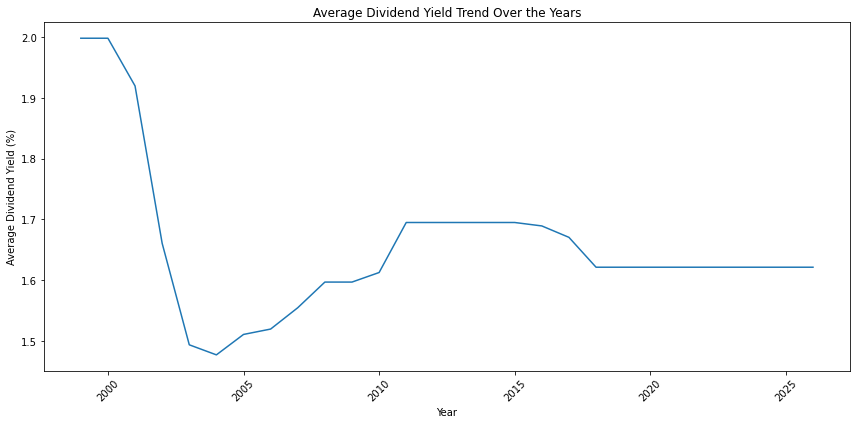

In [63]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_yield,
    x='Year',
    y='Dividend_Yield'
)

plt.title('Average Dividend Yield Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Dividend Yield (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
# Average Dividend Yield by Company
company_yield = (
    df.groupby('Company_Name')['Dividend_Yield']
    .mean()
    .sort_values(ascending=False)
)

company_yield.head(10)

Company_Name
Wipro Ltd.                              7.18
Oil & Natural Gas Corporation Ltd.      6.79
Coal India Ltd.                         6.01
Power Grid Corporation of India Ltd.    5.26
Bharat Petroleum Corporation Ltd.       4.80
ITC Ltd.                                4.45
HCL Technologies Ltd.                   3.14
NTPC Ltd.                               3.12
Infosys Ltd.                            2.74
Tech Mahindra Ltd.                      2.58
Name: Dividend_Yield, dtype: float64

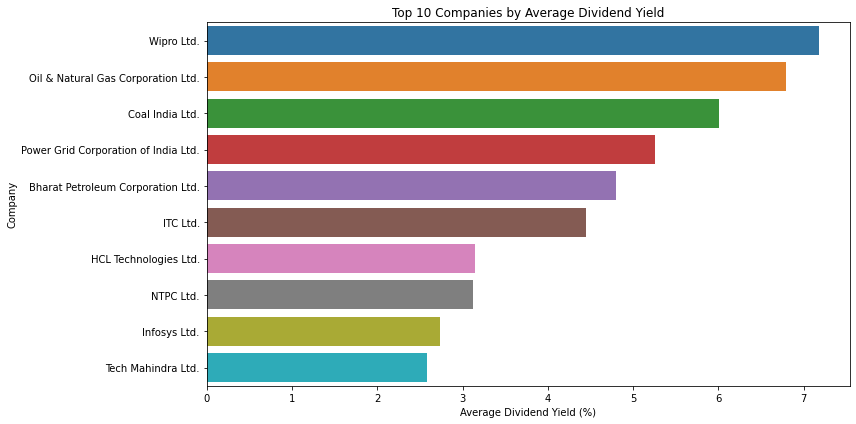

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=company_yield.head(10).values,
    y=company_yield.head(10).index
)

plt.title('Top 10 Companies by Average Dividend Yield')
plt.xlabel('Average Dividend Yield (%)')
plt.ylabel('Company')

plt.tight_layout()
plt.show()

In [66]:
# Average Dividend Yield by Sector
sector_yield = (
    df.groupby('Sector')['Dividend_Yield']
    .mean()
    .sort_values(ascending=False)
)

sector_yield

Sector
Power                4.110323
Energy               3.993333
IT                   3.470047
FMCG                 1.960352
Metals               1.744080
Automobile           1.408634
Telecom              0.810000
Pharma               0.799601
Consumer Durables    0.627854
Financials           0.580196
Cement               0.517581
Infrastructure       0.468325
Healthcare           0.290000
Name: Dividend_Yield, dtype: float64

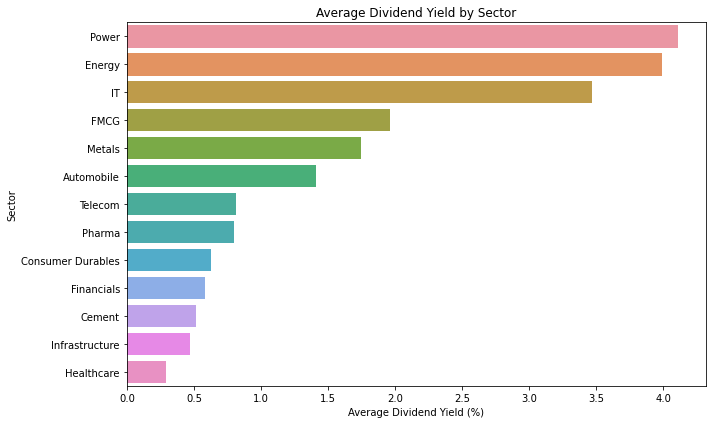

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=sector_yield.values,
    y=sector_yield.index
)

plt.title('Average Dividend Yield by Sector')
plt.xlabel('Average Dividend Yield (%)')
plt.ylabel('Sector')

plt.tight_layout()
plt.show()

In [68]:
# Create Company-Year Analysis
yearly_dividend = (
    df[df['Dividend'] > 0]
    .groupby('Year')['Dividend']
    .sum()
    .reset_index()
)

yearly_dividend.head(10)

,Year,Dividend
0,1999,8.254205
1,2000,9.702284
2,2001,13.546997
3,2002,22.028193
4,2003,50.044783
5,2004,65.867534
6,2005,70.592083
7,2006,80.622687
8,2007,95.604650
9,2008,118.944944


In [69]:
yearly_dividend.tail(10)

,Year,Dividend
18,2017,625.337749
19,2018,597.580025
20,2019,657.682820
21,2020,883.671140
22,2021,956.334120
23,2022,1036.538104
24,2023,1290.582536
25,2024,1362.590184
26,2025,1718.885331
27,2026,75.000000


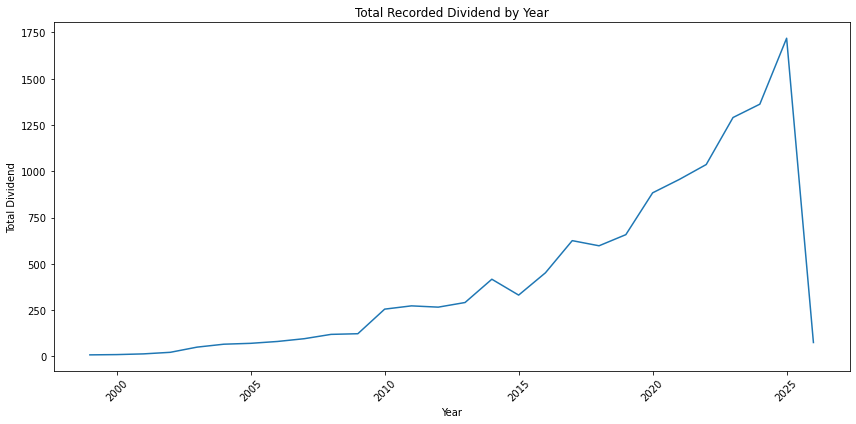

In [70]:
# Total Recorded Dividend by Year
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_dividend,
    x='Year',
    y='Dividend'
)

plt.title('Total Recorded Dividend by Year')
plt.xlabel('Year')
plt.ylabel('Total Dividend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Company-Year Dataset
company_year = (
    df.groupby(['Company_Name', 'Ticker', 'Sector', 'Year'])
      .agg(
          Avg_Dividend_Yield=('Dividend_Yield', 'mean'),
          Total_Dividend=('Dividend', 'sum'),
          Avg_EPS=('EPS', 'mean'),
          Avg_Close=('Close', 'mean'),
          Avg_Market_Cap=('Market_Cap', 'mean')
      )
      .reset_index()
)

In [72]:
company_year.head()

,Company_Name,Ticker,Sector,Year,Avg_Dividend_Yield,Total_Dividend,Avg_EPS,Avg_Close,Avg_Market_Cap
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,0.06,1.454228,64.85,0.026471,2.611735e+12
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,0.06,1.454228,64.85,0.248253,2.611735e+12
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,0.06,1.938970,64.85,2.436733,2.611735e+12
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.06,0.193897,64.85,3.883791,2.611735e+12
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.06,0.218134,64.85,7.341989,2.611735e+12


In [73]:
company_year.shape

(1216, 9)

In [74]:
company_year[
    company_year['Company_Name'] == 'Infosys Ltd.'
].head(10)

,Company_Name,Ticker,Sector,Year,Avg_Dividend_Yield,Total_Dividend,Avg_EPS,Avg_Close,Avg_Market_Cap
651,Infosys Ltd.,INFY.NS,IT,1999,2.74,0.062501,70.89,23.995489,6.638978e+12
652,Infosys Ltd.,INFY.NS,IT,2000,2.74,0.085938,70.89,75.239030,6.638978e+12
653,Infosys Ltd.,INFY.NS,IT,2001,2.74,0.234376,70.89,38.977862,6.638978e+12
654,Infosys Ltd.,INFY.NS,IT,2002,2.74,0.390626,70.89,36.152188,6.638978e+12
655,Infosys Ltd.,INFY.NS,IT,2003,2.74,0.453126,70.89,38.814485,6.638978e+12
656,Infosys Ltd.,INFY.NS,IT,2004,2.74,2.109375,70.89,60.768449,6.638978e+12
657,Infosys Ltd.,INFY.NS,IT,2005,2.74,0.812500,70.89,93.170091,6.638978e+12
658,Infosys Ltd.,INFY.NS,IT,2006,2.74,3.031250,70.89,138.005357,6.638978e+12
659,Infosys Ltd.,INFY.NS,IT,2007,2.74,1.562500,70.89,160.333341,6.638978e+12
660,Infosys Ltd.,INFY.NS,IT,2008,2.74,4.656250,70.89,127.987092,6.638978e+12


In [75]:
yearly_dividend.head(10)

,Year,Dividend
0,1999,8.254205
1,2000,9.702284
2,2001,13.546997
3,2002,22.028193
4,2003,50.044783
5,2004,65.867534
6,2005,70.592083
7,2006,80.622687
8,2007,95.604650
9,2008,118.944944


In [76]:
yearly_dividend.tail(10)

,Year,Dividend
18,2017,625.337749
19,2018,597.580025
20,2019,657.682820
21,2020,883.671140
22,2021,956.334120
23,2022,1036.538104
24,2023,1290.582536
25,2024,1362.590184
26,2025,1718.885331
27,2026,75.000000


In [77]:
company_year.head()

,Company_Name,Ticker,Sector,Year,Avg_Dividend_Yield,Total_Dividend,Avg_EPS,Avg_Close,Avg_Market_Cap
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,0.06,1.454228,64.85,0.026471,2.611735e+12
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,0.06,1.454228,64.85,0.248253,2.611735e+12
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,0.06,1.938970,64.85,2.436733,2.611735e+12
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.06,0.193897,64.85,3.883791,2.611735e+12
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.06,0.218134,64.85,7.341989,2.611735e+12


In [78]:
company_year.shape

(1216, 9)

In [79]:
df[df['Company_Name'] == 'Adani Enterprises Ltd.'][
    ['Year', 'EPS', 'Dividend', 'Dividend_Yield']
].groupby('Year').agg({
    'EPS': 'mean',
    'Dividend': 'sum',
    'Dividend_Yield': 'mean'
}).head(15)

,EPS,Dividend,Dividend_Yield
Year,,,
2002,64.85,1.454228,0.06
2003,64.85,1.454228,0.06
2004,64.85,1.938970,0.06
2005,64.85,0.193897,0.06
2006,64.85,0.218134,0.06
2007,64.85,0.218134,0.06
2008,64.85,0.290846,0.06
2009,64.85,0.484743,0.06
2010,64.85,0.969485,0.06


In [80]:
df.groupby('Company_Name')['EPS'].nunique().sort_values().head(15)

Company_Name
Adani Enterprises Ltd.                  1
Infosys Ltd.                            1
JSW Steel Ltd.                          1
Kotak Mahindra Bank Ltd.                1
LTIMindtree Ltd.                        1
Larsen & Toubro Ltd.                    1
Mahindra & Mahindra Ltd.                1
Maruti Suzuki India Ltd.                1
NTPC Ltd.                               1
Nestle India Ltd.                       1
Oil & Natural Gas Corporation Ltd.      1
Power Grid Corporation of India Ltd.    1
Reliance Industries Ltd.                1
SBI Life Insurance Company Ltd.         1
Shree Cement Ltd.                       1
Name: EPS, dtype: int64

In [81]:
# Analyze dividend trends properly
# Company-Year Dividend Analysis
company_year_dividend = (
    df[df['Dividend'] > 0]
    .groupby(['Company_Name', 'Ticker', 'Sector', 'Year'])
    .agg(
        Total_Dividend=('Dividend', 'sum'),
        Dividend_Events=('Dividend', 'count'),
        Avg_Dividend_Yield=('Dividend_Yield', 'mean')
    )
    .reset_index()
)

company_year_dividend.head()

,Company_Name,Ticker,Sector,Year,Total_Dividend,Dividend_Events,Avg_Dividend_Yield
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,1.454228,1,0.06
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,1.454228,1,0.06
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,1.938970,1,0.06
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.193897,1,0.06
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.218134,1,0.06


In [82]:
company_year_dividend.shape

(1097, 7)

In [83]:
company_year_dividend.head(20)

,Company_Name,Ticker,Sector,Year,Total_Dividend,Dividend_Events,Avg_Dividend_Yield
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,1.454228,1,0.06
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,1.454228,1,0.06
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,1.938970,1,0.06
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.193897,1,0.06
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.218134,1,0.06
5,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2007,0.218134,1,0.06
6,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2008,0.290846,1,0.06
7,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2009,0.484743,1,0.06
8,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2010,0.969485,1,0.06
9,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2011,0.969485,1,0.06


In [84]:
# Dividend Trend Over Time
yearly_dividend = (
    df[df['Dividend'] > 0]
    .groupby('Year')['Dividend']
    .sum()
    .reset_index()
)

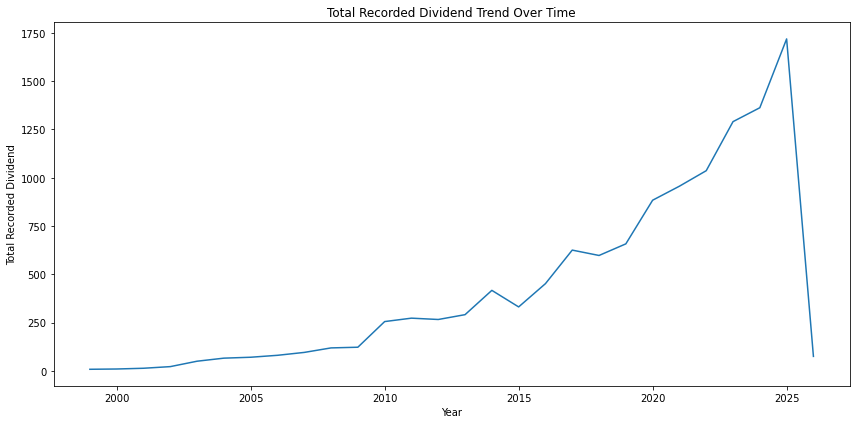

In [85]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_dividend,
    x='Year',
    y='Dividend'
)

plt.title('Total Recorded Dividend Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Total Recorded Dividend')
plt.tight_layout()
plt.show()

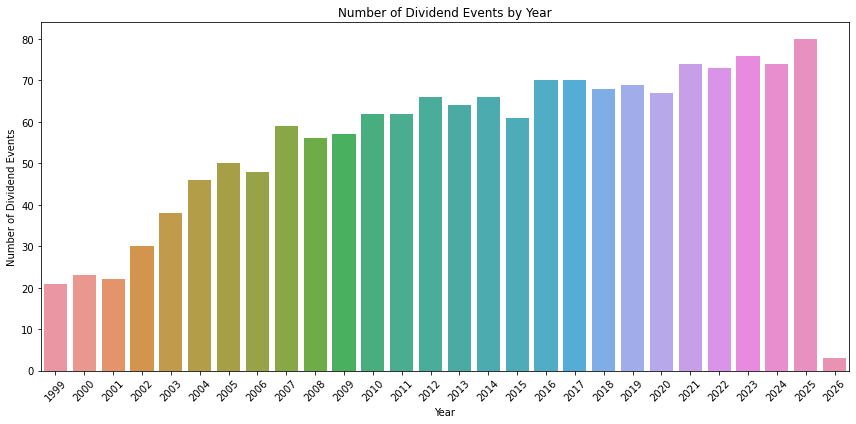

In [86]:
# Chart 5 — Dividend Events by Year
dividend_events_year = (
    df[df['Dividend'] > 0]
    .groupby('Year')
    .size()
    .reset_index(name='Dividend_Events')
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=dividend_events_year,
    x='Year',
    y='Dividend_Events'
)

plt.title('Number of Dividend Events by Year')
plt.xlabel('Year')
plt.ylabel('Number of Dividend Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

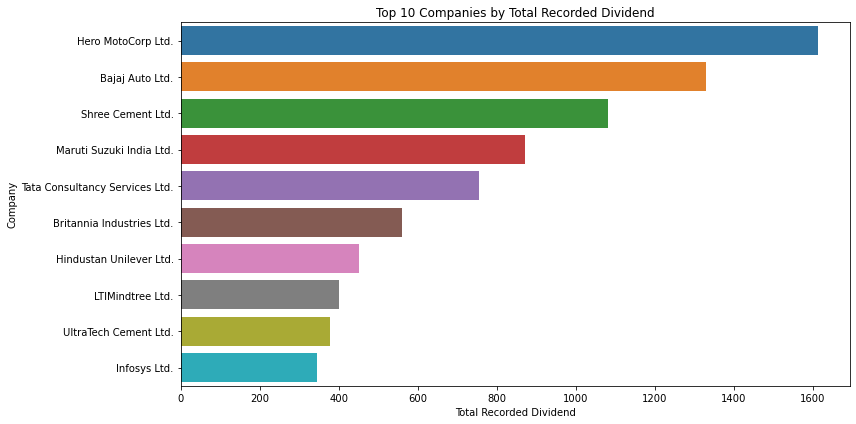

In [87]:
# Chart 6 — Top Companies by Total Recorded Dividend
top_companies = (
    df[df['Dividend'] > 0]
    .groupby('Company_Name')['Dividend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

plt.title('Top 10 Companies by Total Recorded Dividend')
plt.xlabel('Total Recorded Dividend')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

In [88]:
# Dividend Growth Trend.

In [89]:
# Year-over-Year Dividend Growth
# Create the yearly dividend table
yearly_dividend = (
    df[df['Dividend'] > 0]
    .groupby('Year')['Dividend']
    .sum()
    .reset_index()
)

In [90]:
yearly_dividend['Dividend_Growth_%'] = (
    yearly_dividend['Dividend']
    .pct_change() * 100
)

In [91]:
yearly_dividend.head(10)

,Year,Dividend,Dividend_Growth_%
0,1999,8.254205,NaN
1,2000,9.702284,17.543531
2,2001,13.546997,39.626886
3,2002,22.028193,62.605727
4,2003,50.044783,127.185149
5,2004,65.867534,31.617184
6,2005,70.592083,7.172804
7,2006,80.622687,14.209248
8,2007,95.604650,18.582813
9,2008,118.944944,24.413346


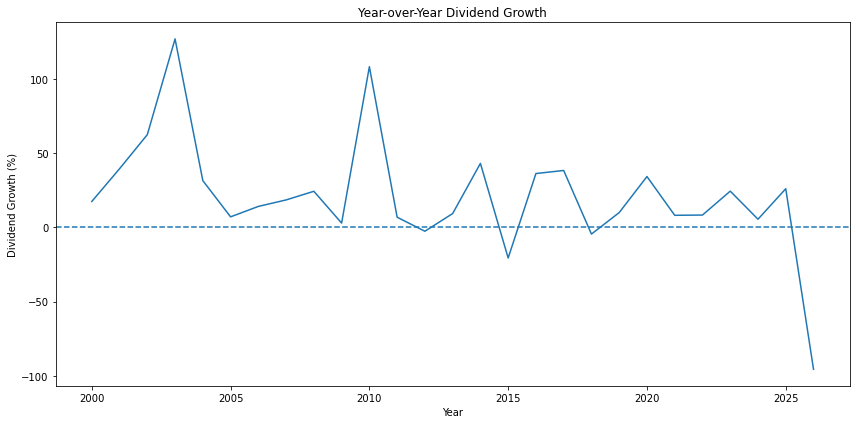

In [92]:
# 📊 Chart 7 — Year-over-Year Dividend Growth
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_dividend,
    x='Year',
    y='Dividend_Growth_%'
)

plt.axhline(0, linestyle='--')

plt.title('Year-over-Year Dividend Growth')
plt.xlabel('Year')
plt.ylabel('Dividend Growth (%)')
plt.tight_layout()
plt.show()

In [93]:
# Company-wise Dividend Growth

company_year_dividend = (
    df[df['Dividend'] > 0]
    .groupby(['Company_Name', 'Ticker', 'Sector', 'Year'])
    .agg(
        Total_Dividend=('Dividend', 'sum'),
        Dividend_Events=('Dividend', 'count'),
        Avg_Dividend_Yield=('Dividend_Yield', 'mean')
    )
    .reset_index()
)
company_year_dividend

,Company_Name,Ticker,Sector,Year,Total_Dividend,Dividend_Events,Avg_Dividend_Yield
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,1.454228,1,0.06
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,1.454228,1,0.06
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,1.938970,1,0.06
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.193897,1,0.06
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.218134,1,0.06
...,...,...,...,...,...,...,...
1092,Wipro Ltd.,WIPRO.NS,IT,2022,3.000000,2,7.18
1093,Wipro Ltd.,WIPRO.NS,IT,2023,0.500000,1,7.18
1094,Wipro Ltd.,WIPRO.NS,IT,2024,0.500000,1,7.18
1095,Wipro Ltd.,WIPRO.NS,IT,2025,11.000000,2,7.18


In [94]:
company_year_dividend['Dividend_Growth_%'] = (
    company_year_dividend
    .groupby('Company_Name')['Total_Dividend']
    .pct_change() * 100
)

In [95]:
company_year_dividend.head(20)

,Company_Name,Ticker,Sector,Year,Total_Dividend,Dividend_Events,Avg_Dividend_Yield,Dividend_Growth_%
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,1.454228,1,0.06,NaN
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,1.454228,1,0.06,0.000000
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,1.938970,1,0.06,33.333287
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.193897,1,0.06,-90.000000
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.218134,1,0.06,12.499936
5,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2007,0.218134,1,0.06,0.000000
6,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2008,0.290846,1,0.06,33.333639
7,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2009,0.484743,1,0.06,66.666552
8,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2010,0.969485,1,0.06,99.999794
9,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2011,0.969485,1,0.06,0.000000


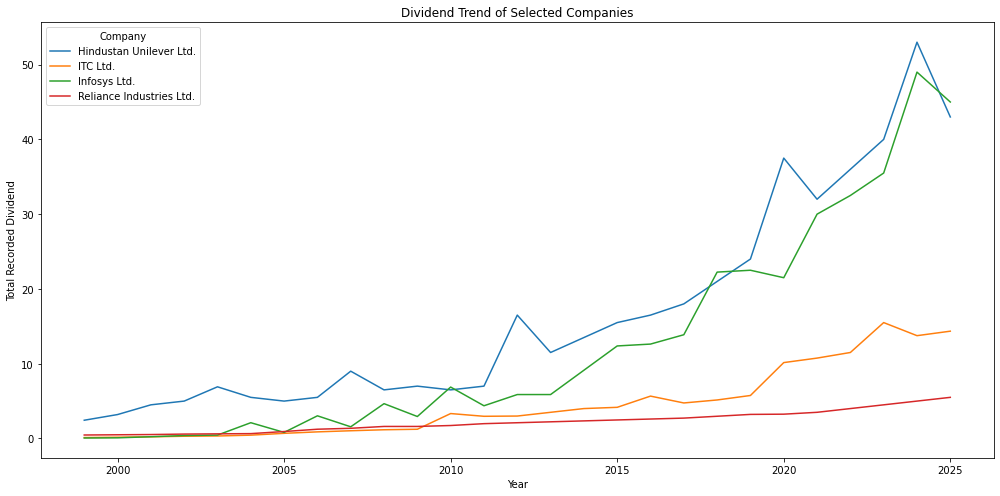

In [96]:
# Chart 8 — Dividend Trend for Selected Companies
selected_companies = [
    'Infosys Ltd.',
    'Reliance Industries Ltd.',
    'Hindustan Unilever Ltd.',
    'ITC Ltd.'
]

trend_data = company_year_dividend[
    company_year_dividend['Company_Name'].isin(selected_companies)
]

plt.figure(figsize=(14,7))

sns.lineplot(
    data=trend_data,
    x='Year',
    y='Total_Dividend',
    hue='Company_Name'
)

plt.title('Dividend Trend of Selected Companies')
plt.xlabel('Year')
plt.ylabel('Total Recorded Dividend')
plt.legend(title='Company')
plt.tight_layout()
plt.show()

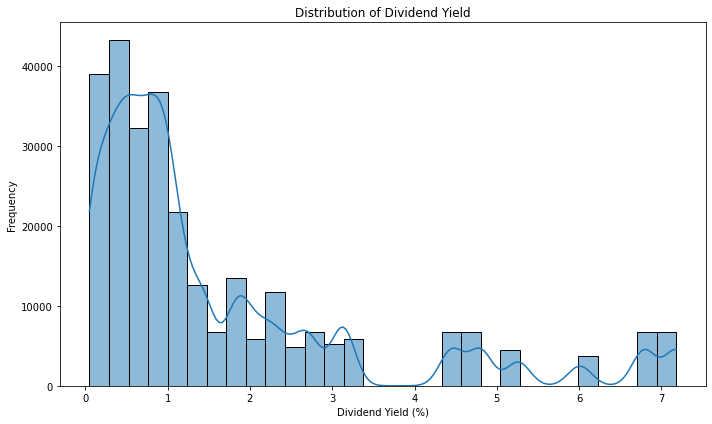

In [97]:
# Step 10 — Dividend Yield Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df['Dividend_Yield'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Dividend Yield')
plt.xlabel('Dividend Yield (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [98]:
# Correlation Analysis
corr_data = df[
    [
        'Dividend',
        'Dividend_Yield',
        'EPS',
        'Close',
        'Market_Cap',
        'PE_Ratio',
        'Beta',
        'Daily_Return',
        'Volatility_20D'
    ]
]

correlation = corr_data.corr()

correlation

,Dividend,Dividend_Yield,EPS,Close,Market_Cap,PE_Ratio,Beta,Daily_Return,Volatility_20D
Dividend,1.000000,0.003150,0.033749,0.044387,-0.005903,0.001179,0.007954,0.000192,-0.001203
Dividend_Yield,0.003150,1.000000,-0.187999,-0.133340,-0.107980,-0.423305,0.121885,-0.001874,-0.008681
EPS,0.033749,-0.187999,1.000000,0.546656,-0.074757,0.050147,0.046868,-0.001892,-0.011633
Close,0.044387,-0.133340,0.546656,1.000000,-0.108869,0.179670,-0.066525,-0.001555,-0.014964
Market_Cap,-0.005903,-0.107980,-0.074757,-0.108869,1.000000,-0.286034,-0.126110,-0.000357,-0.004159
PE_Ratio,0.001179,-0.423305,0.050147,0.179670,-0.286034,1.000000,-0.204132,-0.000824,-0.008394
Beta,0.007954,0.121885,0.046868,-0.066525,-0.126110,-0.204132,1.000000,-0.000079,0.004601
Daily_Return,0.000192,-0.001874,-0.001892,-0.001555,-0.000357,-0.000824,-0.000079,1.000000,0.218473
Volatility_20D,-0.001203,-0.008681,-0.011633,-0.014964,-0.004159,-0.008394,0.004601,0.218473,1.000000


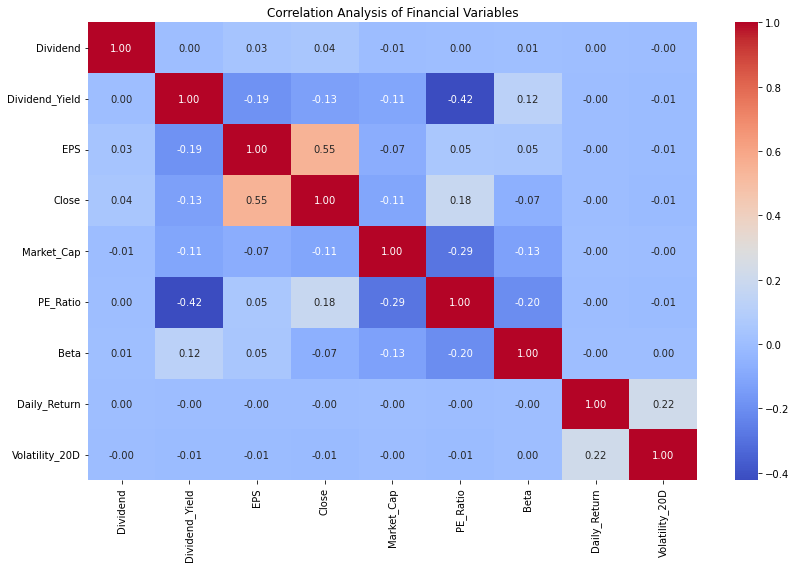

In [99]:
# Chart 10 — Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Analysis of Financial Variables')
plt.tight_layout()
plt.show()


In [100]:
powerbi_data = (
    df.groupby(['Company_Name', 'Ticker', 'Sector', 'Year'])
      .agg(
          Total_Dividend=('Dividend', 'sum'),
          Dividend_Events=('Dividend', lambda x: (x > 0).sum()),
          Avg_Dividend_Yield=('Dividend_Yield', 'mean'),
          Avg_Close=('Close', 'mean'),
          Avg_EPS=('EPS', 'mean'),
          Avg_Market_Cap=('Market_Cap', 'mean'),
          Avg_PE_Ratio=('PE_Ratio', 'mean'),
          Avg_Beta=('Beta', 'mean')
      )
      .reset_index()
)

powerbi_data['Dividend_Growth_%'] = (
    powerbi_data
    .sort_values(['Company_Name', 'Year'])
    .groupby('Company_Name')['Total_Dividend']
    .pct_change() * 100
)

powerbi_data.head()

,Company_Name,Ticker,Sector,Year,Total_Dividend,Dividend_Events,Avg_Dividend_Yield,Avg_Close,Avg_EPS,Avg_Market_Cap,Avg_PE_Ratio,Avg_Beta,Dividend_Growth_%
0,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2002,1.454228,1,0.06,0.026471,64.85,2.611735e+12,31.154974,0.491,NaN
1,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2003,1.454228,1,0.06,0.248253,64.85,2.611735e+12,31.154974,0.491,0.000000
2,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2004,1.938970,1,0.06,2.436733,64.85,2.611735e+12,31.154974,0.491,33.333287
3,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2005,0.193897,1,0.06,3.883791,64.85,2.611735e+12,31.154974,0.491,-90.000000
4,Adani Enterprises Ltd.,ADANIENT.NS,Infrastructure,2006,0.218134,1,0.06,7.341989,64.85,2.611735e+12,31.154974,0.491,12.499936


In [101]:
powerbi_data.shape

(1216, 13)

In [103]:
# Save cleaned dataset
df.to_csv("dividend_analysis_clean.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!
